# Module 3 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

## k Nearest Neighbors and Model Evaluation

In this programming assignment you will use k Nearest Neighbors (kNN) to build a "model" that will estimate the compressive strength of various types of concrete. This assignment has several objectives:

1. Implement the kNN algorithm with k=9. Remember...the data + distance function is the model in kNN. In addition to asserts that unit test your code, you should "test drive" the model, showing output that a non-technical person could interpret.

2. You are going to compare the kNN model above against the baseline model described in the course notes (the mean of the training set's target variable). You should use 10 fold cross validation and Mean Squared Error (MSE):

$$MSE = \frac{1}{n}\sum^n_i (y_i - \hat{y}_i)^2$$

as the evaluation metric ("error"). Refer to the course notes for the format your output should take. Don't forget a discussion of the results.

3. use validation curves to tune a *hyperparameter* of the model. 
In this case, the hyperparameter is *k*, the number of neighbors. Don't forget a discussion of the results.

4. evaluate the *generalization error* of the new model.
Because you may have just created a new, better model, you need a sense of its generalization error, calculate that. Again, what would you like to see as output here? Refer to the course notes. Don't forget a discussion of the results. Did the new model do better than either model in Q2?

5. pick one of the "Choose Your Own Adventure" options.

Refer to the "course notes" for this module for most of this assignment.
Anytime you just need test/train split, use fold index 0 for the test set and the remainder as the training set.
Discuss any results.

## Load the Data

The function `parse_data` loads the data from the specified file and returns a List of Lists. The outer List is the data set and each element (List) is a specific observation. Each value of an observation is for a particular measurement. This is what we mean by "tidy" data.

The function also returns the *shuffled* data because the data might have been collected in a particular order that *might* bias training.

In [1]:
import random
from typing import List, Dict, Tuple, Callable

In [2]:
def parse_data(file_name: str) -> List[List]:
    data = []
    file = open(file_name, "r")
    for line in file:
        datum = [float(value) for value in line.rstrip().split(",")]
        data.append(datum)
    random.shuffle(data)
    return data

In [3]:
data = parse_data("concrete_compressive_strength.csv")

In [4]:
data[0]

[142.0, 167.0, 130.0, 174.0, 11.0, 883.0, 785.0, 28.0, 44.61]

In [5]:
len(data)

1030

There are 1,030 observations and each observation has 8 measurements. The data dictionary for this data set tells us the definitions of the individual variables (columns/indices):

| Index | Variable | Definition |
|-------|----------|------------|
| 0     | cement   | kg in a cubic meter mixture |
| 1     | slag     | kg in a cubic meter mixture |
| 2     | ash      | kg in a cubic meter mixture |
| 3     | water    | kg in a cubic meter mixture |
| 4     | superplasticizer | kg in a cubic meter mixture |
| 5     | coarse aggregate | kg in a cubic meter mixture |
| 6     | fine aggregate | kg in a cubic meter mixture |
| 7     | age | days |
| 8     | concrete compressive strength | MPa |

The target ("y") variable is a Index 8, concrete compressive strength in (Mega?) [Pascals](https://en.wikipedia.org/wiki/Pascal_(unit)).

## Train/Test Splits - n folds

With n fold cross validation, we divide our data set into n subgroups called "folds" and then use those folds for training and testing. You pick n based on the size of your data set. If you have a small data set--100 observations--and you used n=10, each fold would only have 10 observations. That's probably too small. You want at least 30. At the other extreme, we generally don't use n > 10.

With 1,030 observations, n = 10 is fine so we will have 10 folds.
`create_folds` will take a list (xs) and split it into `n` equal folds with each fold containing one-tenth of the observations.

In [6]:
def create_folds(xs: List, n: int) -> List[List[List]]:
    k, m = divmod(len(xs), n)
    # be careful of generators...
    return list(xs[i * k + min(i, m):(i + 1) * k + min(i + 1, m)] for i in range(n))

In [7]:
folds = create_folds(data, 10)

In [8]:
len(folds)

10

We always use one of the n folds as a test set (and, sometimes, one of the folds as a *pruning* set but not for kNN), and the remaining folds as a training set.
We need a function that'll take our n folds and return the train and test sets:

In [9]:
def create_train_test(folds: List[List[List]], index: int) -> Tuple[List[List], List[List]]:
    training = []
    test = []
    for i, fold in enumerate(folds):
        if i == index:
            test = fold
        else:
            training = training + fold
    return training, test

We can test the function to give us a train and test datasets where the test set is the fold at index 0:

In [10]:
train, test = create_train_test(folds, 0)

In [11]:
len(train)

927

In [12]:
len(test)

103

## Answers

Answer the questions above in the space provided below, adding cells as you need to.
Put everything in the helper functions and document them.
Document everything (what you're doing and why).
If you're not sure what format the output should take, refer to the course notes and what they do for that particular topic/algorithm.

## Problem 1: kNN

Implement k Nearest Neighbors with k = 9.

In [13]:
#import necessary libraries
import math
from operator import itemgetter
import copy
import numpy as np

<a id="euclidean_distance"></a>
## euclidean_distance

The euclidean distance is a distance metric that measures the length of a line segment between two points, in n dimensions. In the k-nearest neighbor algorithm, it is used to calculate how close each training data point is to the query point. The k datapoints with the lowest euclidean distance are considered the k-nearest neighbors and are used to predict a value.    

$$ d(p, q) = \sqrt{(p_{1}-q_{1})^2 + (p_{2}-q_{2})^2 + (p_{n}-q_{n})^2} $$

* **datapoint** List[float]: training datapoint to be evaluated
* **query** List[float]: test datapoint to be evaluated
  
**returns** **euclidean_distance** float: calculated euclidean distance between the two inputted points

In [14]:
def euclidean_distance(datapoint: list[float], query: list[float]) -> float:
    squared_distance = 0
    for i in range(len(datapoint) - 1):
        difference = (datapoint[i] - query[i]) ** 2
        squared_distance = squared_distance + difference
    return math.sqrt(squared_distance)

In [15]:
testpoint1 = [1, 3]
testpoint2 = [7, 3]
testpoint3 = [-1, 3]

assert euclidean_distance(testpoint1, testpoint2) == 6
assert euclidean_distance(testpoint1, testpoint1) == 0
assert euclidean_distance(testpoint1, testpoint3) == 2

<a id="knn_predict"></a>
## knn_predict

K-nearest neighbor is a supervised learning algorithm that is often used to solve both classification and regression problems. The algorithm is based on the idea that datapoints that are similar to each other are in close proximity, or clustered. A distance metric is used to calculate the k-nearest neighbors of a quesry test data point. For a classification problem, the mode of the k labels is predicted, and for regression problems, the mean of the k labels is predicted.

Given a regression training set, a regression test set and a k value, this function finds the k-nearest neighbors for each data point in the test set. The euclidean distance is used as the distance metric. The mean of the dependent variable (last element in row) of the k-nearest neighbors is calculated as the prediction for a test data point. The function return a list of the prediction for the test set. 

* **train** List[List[float]]: training data to be used by the model
* **test** List[List[float]]: testing data to be predicted by the model
* **k** int: the number of closest neighbors to be evaluated for prediction
  
**returns** **predictions** List[float]: list of predictions for the test dataset

In [16]:
def knn_predict(train: list[list[float]], test: list[float], k: int) -> float:
    predictions = []
    for test_row in test: 
        distances = {}
        for train_row in train:
            distance = euclidean_distance(train_row, test_row)
            distances[tuple(train_row)] = distance
        top_k = dict(sorted(distances.items(), key=itemgetter(1))[:k])

        prediction = 0
        for key in top_k:
            prediction = prediction + key[-1]
        prediction = prediction / k
        predictions.append(prediction)  
        
    return predictions

In [17]:
test_trainingset = [[1, 2, 4, 7], [5, 6, 2, 3], [6, 1, 4, 5], [5, 4, 1, 4], [3, 9, 1, 0]]

test_testingset = [[9, 2, 1, 5], [4, 2, 5, 1]]

prediction = knn_predict(test_trainingset, test_testingset, 2)
assert len(prediction) == len(test_testingset)
assert prediction[0] == 4.5
assert prediction[1] == 6.0

<a id="knn_fold"></a>
## knn_fold

Cross validation is a resampling method used to effectively evaluate machine learning models when data availability is limited. The dataset is shiffled and divided into n number of folds. Iteratively, each fold is taken as the test set, while the remaining folds are taken as the training set. The folds are iterated through and fitted and run through the model, n number of times, resulting in n evaluations of the model. 

This function iterates through the list of folds inputted into the function and applies the k-nearest neighbor regression model. 

* **folds** List[List[List[float]]]: dataset divided into 
* **k** int: the number of nearest neighbors to be used for the prediction
  
**returns** **test_results** dict{int: List[list[float]]: dictionary containing the fold number as the key and the test dataset with the prediction as the value.

In [18]:
def knn_fold(folds: list[list[list[float]]], k: int) -> dict:
    test_predictions = {}
    train_predictions = {}
    for i in range(len(folds)):
        train, test = create_train_test(folds, i)

        #finding prediction on test set
        prediction = knn_predict(train, test, k)

        test_set = copy.deepcopy(test)
        for j in range(len(test_set)):
            test_set[j].append(prediction[j])
        
        test_predictions[i]= test_set

        #finding prediction on train set
        prediction = knn_predict(train, train, k)

        train_set = copy.deepcopy(train)
        for x in range(len(train_set)):
            train_set[x].append(prediction[x])
        
        train_predictions[i]= train_set
    
    return test_predictions, train_predictions

In [19]:
test_folds = [
            [[1, 2, 4, 7], [5, 6, 2, 3]], 
            [[6, 1, 4, 5], [5, 4, 1, 4]], 
            [[3, 9, 1, 0], [4, 2, 7, 1]], 
            [[9, 2, 1, 5], [4, 2, 5, 1]]
            ]

test_prediction, train_prediction = knn_fold(test_folds, 2)
assert len(test_prediction) == 4
assert len(test_prediction[0]) == 2
assert len(test_prediction[0][0]) == 5

## apply k-nearest neighbor on dataset

In [20]:
folds_copy = copy.deepcopy(folds)
test_prediction, train_prediction = knn_fold(folds_copy, 9)

for key, value in test_prediction.items():
    print(f"\nFold: {key}")
    for line in value: 
        print(f"Input: {line[:-2]},    Target: {line[-2]},    Prediction: {line[-1]}")


Fold: 0
Input: [142.0, 167.0, 130.0, 174.0, 11.0, 883.0, 785.0, 28.0],    Target: 44.61,    Prediction: 29.556666666666665
Input: [160.0, 128.0, 122.0, 182.0, 6.4, 824.0, 879.0, 28.0],    Target: 39.4,    Prediction: 28.149999999999995
Input: [190.3, 0.0, 125.2, 166.6, 9.9, 1079.0, 798.9, 14.0],    Target: 19.42,    Prediction: 21.32111111111111
Input: [145.9, 230.5, 0.0, 202.5, 3.4, 827.0, 871.8, 28.0],    Target: 32.72,    Prediction: 27.891111111111112
Input: [145.7, 172.6, 0.0, 181.9, 3.4, 985.8, 816.8, 28.0],    Target: 23.74,    Prediction: 21.93
Input: [190.3, 0.0, 125.2, 166.6, 9.9, 1079.0, 798.9, 56.0],    Target: 31.72,    Prediction: 34.29666666666667
Input: [387.0, 20.0, 94.0, 157.0, 13.9, 938.0, 845.0, 3.0],    Target: 25.51,    Prediction: 41.5
Input: [362.6, 189.0, 0.0, 164.9, 11.6, 944.7, 755.8, 28.0],    Target: 71.3,    Prediction: 50.55444444444444
Input: [141.3, 212.0, 0.0, 203.5, 0.0, 971.8, 748.5, 90.0],    Target: 39.66,    Prediction: 31.203333333333333
Input: 

The above cell shows the predictions made on the test data points. The input values of the independent features, the target/actual value for the concrete compressive strength and the predicted value for each data point is displayed. 

## Problem 2: Evaluation vs. The Mean

Using Mean Squared Error (MSE) as your evaluation metric, evaluate your implement above and the Null model, the mean.

<a id="mean_square_error"></a>
## mean_square_error

Mean square error is an evaluation metric often used for regression problems, where the target and predicted variables are numerical. The mean square error follows the following formula: 

$$MSE = \frac{1}{n}\sum^n_i (y_i - \hat{y}_i)^2$$

The mean square error functions by penalizing larger errors more than smaller errors. 

* **prediction_dataset** List[List[List[float]]]: dataset in which the second-last column is the target value, and the last column is the predicted value
  
**returns** **mse** float: calculated mean square error between actual and predicted values

In [21]:
def mean_square_error(prediction) -> float:
    square_error = 0
    for i in range(len(prediction)):
        actual_value = prediction[i][-2]
        predicted_value = prediction[i][-1]
        difference_square = (actual_value - predicted_value) ** 2
        square_error = square_error + difference_square
    mse = square_error / len(prediction)
    return mse 

In [22]:
trial_predictions = {1:[[1, 3, 4, 5], [3, 2, 7, 3]], 2:[[0, 2, 3, 3], [4, 6, 2, 4]], 3:[[1, 3, 2, 5], [3, 4, 2, 4]]}
assert mean_square_error(trial_predictions[1]) == 8.5
assert mean_square_error(trial_predictions[2]) == 2
assert mean_square_error(trial_predictions[3]) == 6.5

<a id="evaluate"></a>
## evaluate

To evaluate a model, it is best to train the model with the training set, and test the model on both the testing set and the training set. This helps in evaluating overfitting and underfitting. This function calculates the mean square value for the 

* **test_prediction** List[List[float]]: testing dataset in which the second-last column is the target value, and the last column is the predicted value
* **train_prediction** List[List[float]]: training dataset in which the second-last column is the target value, and the last column is the predicted value
  
**returns** **test_error** List[float]: list of mean square error calculated with each fold on test set, **train_error** List[float]: list of mean square error calculated on training set with each fold

In [23]:
def evaluate(test_prediction, train_prediction):
    fold_error = []
    test_error = []
    train_error = []
    
    for fold, fold_prediction in test_prediction.items():
        test_mse = mean_square_error(test_prediction[fold])
        train_mse = mean_square_error(train_prediction[fold])
        fold_error.append([fold, test_mse, train_mse])
        test_error.append(test_mse)
        train_error.append(train_mse)

    test_average = sum(test_error)/len(test_error)
    train_average = sum(train_error)/len(train_error)
    test_std = (sum([((x - test_average) ** 2) for x in test_error]) / len(test_error)) ** 0.5
    train_std = (sum([((x - train_average) ** 2) for x in train_error]) / len(train_error)) ** 0.5

    
    print ("{:<8} {:<20} {:<10}".format('Fold','Test','Train'))
    for list in fold_error:
        print("{:<8} {:<20} {:<10}".format(list[0],list[1],list[2]))
    print ("{:<8} {:<20} {:<10}".format('Average', test_average, train_average))
    print ("{:<8} {:<20} {:<10}".format('STD', test_std, train_std))

    return test_error, train_error

In [24]:
trial_predictions = {1:[[1, 3, 4, 5], [3, 2, 7, 3]], 2:[[0, 2, 3, 3], [4, 6, 2, 4]], 3:[[1, 3, 2, 5], [3, 4, 2, 4]]}
trial2_predictions = {1:[[3, 5, 1, 3], [5, 3, 2, 6]], 2:[[0, 2, 3, 3], [4, 6, 2, 4]], 3:[[1, 3, 2, 5], [3, 4, 2, 4]]}

test_error, train_error = evaluate(trial_predictions, trial2_predictions)
assert len(test_error) == 3
assert len(train_error) == 3

Fold     Test                 Train     
1        8.5                  10.0      
2        2.0                  2.0       
3        6.5                  6.5       
Average  5.666666666666667    6.166666666666667
STD      2.7182510717166815   3.2744804507314167


## apply mean square error on dataset

In [25]:
print("Mean Square Error")
mse_test, mean_train = evaluate(test_prediction, train_prediction)

Mean Square Error
Fold     Test                 Train     
0        103.77895750928924   69.4590323731139
1        61.86381319669187    72.90853360235465
2        120.85526255543574   69.6181066216522
3        77.3032970274482     70.14293458920982
4        93.99662128730672    70.62515680743671
5        77.39456820088698    71.30404157044491
6        75.93333165527987    72.07039800764447
7        95.88649436653478    71.95996915444752
8        104.43432068800195   69.23687831582038
9        107.2885144432458    73.20615546898935
Average  91.87351809301211    71.05312065111139
STD      17.246134881025753   1.3751005608530185


In [26]:
#setting up mean model
test_prediction_mean = copy.deepcopy(test_prediction)
train_prediction_mean = copy.deepcopy(train_prediction)

#calculate mean
mean = 0
for i in range(len(data)):
    mean = mean + data[i][-1]
mean = mean / len(data)

#setting all prediction values as mean
for key, value in test_prediction_mean.items():
    for j in range(len(value)):
        test_prediction_mean[key][j][-1] = mean

for key, value in train_prediction_mean.items():
    for k in range(len(value)):
        train_prediction_mean[key][k][-1] = mean

print("Mean Model")
mean_test, mean_train = evaluate(test_prediction_mean, train_prediction_mean)

Mean Model
Fold     Test                 Train     
0        266.02726173060614   280.231261229983
1        231.17450847393718   284.10378936961297
2        336.98172368743525   272.3474321236687
3        250.11565800735227   281.9992171992334
4        285.2864285229521    278.09135380861113
5        278.50444814779894   278.84490718362815
6        248.41057882929584   282.18867044123937
7        286.63106360637187   277.9419499104534
8        321.3004531435573    274.08979551743266
9        283.67648865114523   278.27023601658954
Average  278.8108612800452    278.81086128004523
STD      30.816076639095975   3.4240085154551143


The average mean square error for the kNN model (91.87) was found to be significantly lower than that of the mean model (278.81). This suggests that the kNN model works more efficiently than assuming that the mean of the dependent variable column is the predicted value of each data point in the dataset, making it a good contender model for regression on this dataset. However, with the average mean square error still being on the higher side of 91.97, the k-NN regression model requires further finetuning to combat this. 

## Problem 3: Hyperparameter Tuning

Tune the value of k.

In [27]:
k_test = {}
k_train = {}
for k in range(1,21,1):
    folds_copy = copy.deepcopy(folds)
    print(f"\nk = {k}")
    test_prediction, train_prediction = knn_fold(folds_copy, k)
    mse_test, mse_train = evaluate(test_prediction, train_prediction)
    k_test[k]= sum(mse_test) / len(mse_test)
    k_train[k]= sum(mse_train) / len(mse_train)


k = 1
Fold     Test                 Train     
0        58.93147766990292    1.9150566343042068
1        78.71375339805826    2.0202331175836026
2        100.33733203883494   1.803185113268608
3        62.7436699029126     1.838415426105717
4        80.28996504854373    2.0202331175836026
5        99.22449708737861    1.5872226537216825
6        75.92925242718445    1.8091003236245953
7        64.09864660194178    1.978905717367853
8        124.51414077669901   2.0084008629989207
9        83.70009611650488    0.6670238403451993
Average  82.84828310679613    1.7647776806903988
STD      19.261585432799528   0.3877825707949749

k = 2
Fold     Test                 Train     
0        70.89896407766989    19.7834120819849
1        84.17540315533981    20.996461299892125
2        90.85588883495146    20.432795091693638
3        58.411015533980596   21.237422599784242
4        92.0367626213592     19.647008522114344
5        82.60233834951454    21.111378910463852
6        99.62210097087379 

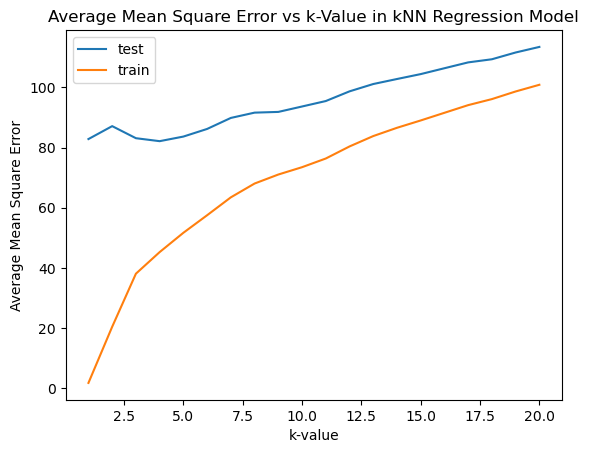

In [28]:
import matplotlib.pyplot as plt

plt.plot(k_test.keys(), k_test.values(), label = "test") 
plt.plot(k_train.keys(), k_train.values(), label = "train") 
plt.legend() 
plt.xlabel("k-value")
plt.ylabel("Average Mean Square Error")
plt.title("Average Mean Square Error vs k-Value in kNN Regression Model")

plt.show()

As the k-value increases, the model complexity also increases, so this plot can also be evaluated as a bias-variance tradeoff. Overall, as the k-value increases, the MSE also increases. This suggests that the data points may be more spread out in the dataset, compared to tighter clusters. Hence, lower k-values would give a closer predicted value to the target value. In the lower k-values, there appears to be a bit of fluctuation in the average MSE before increasing. The lowest average MSE is observed for k = 4, hence may be the optimum k value for this dataset.

## Problem 4: Generalization Error

Analyze and discuss the generalization error of your model with the value of k from Problem 3.

In problem 3, the optimum k-value was found at k = 4. The generalization error is a measure of how a model works on unseen data. In other words, it is the performance of the model on the test set, across the 10-fold cross validation. The average MSE on the test fold is 82.145, with a standard deviation of 14.43. If using k = 4, this is the expected error in the model on unseen data in a real-world setting. 

The generalization error of 82.145 is still on the higher side for deployment into the real-world. This suggests that the model still require fine-tuning to achieve a lower error, if possible. 

## Q5: Choose your own adventure

You have three options for the next part:

1. You can implement mean normalization (also called "z-score standardization") of the *features*; do not normalize the target, y. See if this improves the generalization error of your model (middle).

2. You can implement *learning curves* to see if more data would likely improve your model (easiest).

3. You can implement *weighted* kNN and use the real valued GA to choose the weights. weighted kNN assigns a weight to each item in the Euclidean distance calculation. For two points, j and k:
$$\sqrt{\sum w_i (x^k_i - x^j_i)^2}$$

You can think of normal Euclidean distance as the case where $w_i = 1$ for all features  (ambitious, but fun...you need to start EARLY because it takes a really long time to run).

The easier the adventure the more correct it must be...

#### Option 2: Learning Curve

In [29]:
def knn_learning_curve(folds: list[list[list[float]]], k: int) -> dict:
    test_predictions = {}
    train_predictions = {}
    for i in range(len(folds)):
        training = []
        test = []
        for j, fold in enumerate(folds):
            if j <= i and j != len(folds)- 1:
                test += fold
            else:
                training += fold

        #finding prediction on test set
        prediction = knn_predict(training, test, k)

        test_set = copy.deepcopy(test)
        for l in range(len(test_set)):
            test_set[l].append(prediction[l])
        
        test_predictions[i]= test_set

        #finding prediction on train set
        prediction = knn_predict(training, training, k)

        train_set = copy.deepcopy(training)
        for m in range(len(train_set)):
            train_set[m].append(prediction[m])
        
        train_predictions[i]= train_set
    
    return test_predictions, train_predictions

Fold     Test                 Train     
0        103.77895750928924   69.4590323731139
1        83.56533651564187    73.70530830786291
2        100.07448566462901   74.94957643533503
3        97.41474116624698    79.37262764992607
4        107.82839017859291   86.43644591633708
5        117.18957370849813   93.30675219645214
6        123.6851895241518    113.66445945103682
7        136.835025641256     131.31966847656727
8        158.24763922383366   164.03677587198854
9        158.24763922383366   164.03677587198854
Average  118.68669783559733   105.02874225506085
STD      24.205967113954756   34.67292491007972


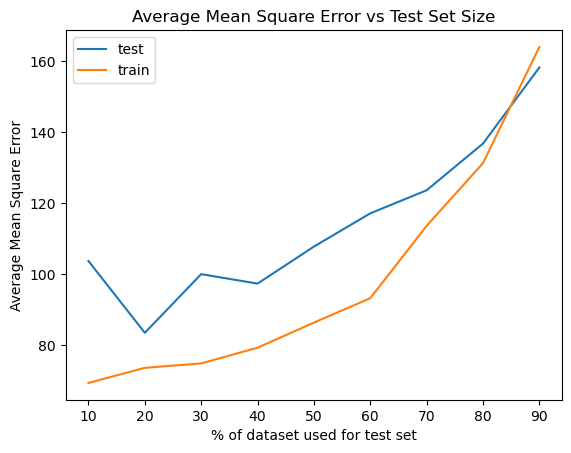

In [30]:
folds_copy = copy.deepcopy(folds)
learning_test_prediction, learning_train_prediction = knn_learning_curve(folds_copy, 9)
mse_test, mse_train = evaluate(learning_test_prediction, learning_train_prediction)

plt.plot([10,20,30,40,50,60,70,80,90], mse_test[:-1], label = "test") 
plt.plot([10,20,30,40,50,60,70,80,90], mse_train[:-1], label = "train") 
plt.legend() 
plt.xlabel("% of dataset used for test set")
plt.ylabel("Average Mean Square Error")
plt.title("Average Mean Square Error vs Test Set Size")

plt.show()

Overall, the trend shows that the average mean square error increases as the size of the test set increases. It should be noted that as we are working with a fixed dataset size, as the test set size increases, the training set size decreases. 

From 10% to 40% test dataset size, the performance of the model fluctuates before a steady increase in error as the test size increases. The optimum size of the test set is found to be 20% of the total dataset. Hence, the optimal results may be found with a 5-fold cross validation, rather than a 10-fold cross validation. At 20% of the dataset for the test set, the difference between the MSE of the training set and the testing set is minimal, suggesting that the model is not overfitted to the data. 

At higher test data set sizes, the training set gets smaller and shows a much higher error rate, suggesting that the model is undefitted to the data. 

## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.